<a href="https://colab.research.google.com/github/holaamigoo/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9613_%D0%93%D0%B5%D0%BE%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D1%8D%D0%BA%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D1%84%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геоанализ экологических факторов городской среды с применением методов пространственной кластеризации**




















## **Цель работы**



Освоение методов пространственного анализа и машинного обучения для оценки экологической обстановки городской территории с использованием гексагональной сетки H3, с последующим применением различных алгоритмов кластеризации и классификации.

## **Задачи**



1. Освоить инструменты загрузки и агрегации экологических геоданных с использованием API OpenStreetMap
2. Реализовать анализ пространственного распределения экологических факторов с помощью гексагональной сетки H3
3. Применить и сравнить различные алгоритмы кластеризации для выявления однородных экологических зон
4. Обучить модели классификации для прогнозирования экологического состояния новых территорий

## **Теоретическая часть**



Современный геоэкологический анализ требует комплексного подхода к обработке пространственно-распределенных данных. Применение методов машинного обучения, в частности алгоритмов кластеризации (K-means, агломеративной, спектральной, DBSCAN, HDBSCAN), позволяет выявлять неявные закономерности в распределении экологических факторов городской среды и определять территории со схожими экологическими характеристиками.

## **Этапы работы**



### **1. Определение области исследования и подготовка данных**


- Выберите городскую территорию для анализа экологической обстановки
- Используя API OpenStreetMap, загрузите данные следующих категорий:
  - Источники загрязнения (промышленные предприятия, мусоропереработка, ТЭЦ)
  - Зеленые насаждения (парки, скверы, лесопарковые зоны)
  - Водные объекты (реки, водоемы)
  - Автомагистрали (категории дорог с интенсивным движением)
  - Административные районы города

In [12]:
!pip install scikit-learn geopandas h3pandas h3~=3.0 leafmap mapclassify matplotlib streamlit osmnx openrouteservice polyline -q
import geopandas as gpd
import pandas as pd
import numpy as np
import h3
import h3pandas
import leafmap
from shapely.geometry import box
from sklearn.preprocessing import MinMaxScaler

In [19]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [18]:
from google.colab import output
output.enable_custom_widget_manager()

In [20]:
bbox = m.user_roi_bounds()
bbox = [37.1282, 55.9446, 37.275, 56.0226]
print(m.center)
print(bbox)

[58.938673187948304, 41.18241069499199]
[37.1282, 55.9446, 37.275, 56.0226]


In [21]:
place_name = "Зеленоград"

In [22]:
import osmnx as ox
import warnings

# Функция загрузки данных из OSM
def load_osm_data(bbox):
    west, south, east, north = bbox  # bbox = (west, south, east, north)

    # Теги для поиска
    tags = {
      'pollution_sources': {'landuse': ['industrial', 'landfill'], 'power': 'plant', 'man_made': 'works'},
      'green_spaces': {'leisure': ['park', 'garden'], 'natural': 'wood', 'landuse': 'forest'},
      'water_bodies': {'waterway': 'river', 'natural': 'water', 'water': ['lake', 'reservoir', 'pond']},
      'highways': {'highway': ['primary', 'trunk', 'motorway', 'secondary', 'tertiary']},
      'administrative_districts': {'boundary': 'administrative', 'admin_level': '8'}
    }

    # Загрузка данных с обработкой исключений
    data = {}
    for key, tag in tags.items():
        print(f"Загрузка {key}...")
        try:
            gdf = ox.features_from_bbox((west, south, east, north), tags=tag)
            data[key] = gdf
        except:
            print(f"Нет данных для {key} в заданном регионе. Создаём пустой GeoDataFrame.")
            # Создаём пустой GeoDataFrame с колонкой 'geometry' и устанавливаем CRS
            data[key] = gpd.GeoDataFrame(columns=['geometry'], crs="EPSG:4326")

    return data

m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.1282, 55.9446, 37.275, 56.0226]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
data = load_osm_data(bbox)

# Приводим данные к нужному CRS
crs_proj = "EPSG:3857"
for key in data.keys():
    # Проверяем, что GeoDataFrame не пустой
    if not data[key].empty and 'geometry' in data[key].columns:
        data[key] = data[key].to_crs(crs_proj)
    else:
        # Если пустой, создаём пустой GeoDataFrame с нужным CRS и колонкой 'geometry'
        data[key] = gpd.GeoDataFrame(columns=['geometry'], crs=crs_proj)

Область не выбрана. Используем значение по умолчанию: [37.1282, 55.9446, 37.275, 56.0226]
Загрузка pollution_sources...
Загрузка green_spaces...
Загрузка water_bodies...
Загрузка highways...
Загрузка administrative_districts...


### **2. Агрегация данных с использованием гексагональной сетки H3**


- Сгенерируйте гексагональную сетку H3 оптимального разрешения для выбранной территории
- Для каждой ячейки H3 рассчитайте:
  - Количество и плотность источников загрязнения в радиусе 1600м
  - Площадь и процент покрытия зелеными насаждениями в радиусе 800м
  - Протяженность водных объектов в радиусе 1600м
  - Плотность автомагистралей в радиусе 1600м
- Выполните нормализацию полученных показателей
- Сформируйте интегральный индекс экологического благополучия территории


In [23]:
from shapely.geometry import box, Polygon

# Функция анализа для каждой H3 ячейки
def analyze_h3_cell(geom):
    buffer_1600m = geom.buffer(1600)
    buffer_800m = geom.buffer(800)
    num_pollution = data['pollution_sources'][data['pollution_sources'].geometry.intersects(buffer_1600m)].shape[0]
    water_length = data['water_bodies'][data['water_bodies'].geometry.intersects(buffer_1600m)].length.sum()
    highways_length = data['highways'][data['highways'].geometry.intersects(buffer_1600m)].length.sum()
    green_area = data['green_spaces'][data['green_spaces'].geometry.intersects(buffer_800m)].area.sum()
    return num_pollution, water_length, highways_length, green_area

# Генерация H3-сетки
resolution = 9  # Можно настроить разрешение

# Создаем полигон bbox
bbox_polygon = box(*bbox)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_polygon], crs="EPSG:4326").to_crs(crs_proj)

# Получаем индексы H3 внутри bbox
h3_indexes = list(h3.polyfill_geojson(bbox_polygon.__geo_interface__, resolution))

# Импортируем Polygon из shapely.geometry
from shapely.geometry import Polygon

# Создаем GeoDataFrame с H3 ячейками
h3_geometries = [Polygon(h3.h3_to_geo_boundary(h, geo_json=True)) for h in h3_indexes]
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_indexes, 'geometry': h3_geometries}, crs="EPSG:4326").to_crs(crs_proj)

# Применяем анализ к каждой H3 ячейке
features = ['num_pollution', 'water_length', 'highways_length', 'green_area']
h3_gdf[features] = h3_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_h3_cell(geom))
)

# Нормализация результатов
scaler = MinMaxScaler()
h3_gdf[features] = scaler.fit_transform(h3_gdf[features])

# Вычисление итогового индекса
features_good = ['water_length', 'green_area']
features_bad = ['num_pollution', 'highways_length']
h3_gdf['index_score'] = h3_gdf[features_good].sum(axis=1) - h3_gdf[features_bad].sum(axis=1)

In [24]:
h3_gdf[features].describe()

,num_pollution,water_length,highways_length,green_area
count,807.000000,807.000000,807.000000,807.000000
mean,0.213680,0.207263,0.326320,0.309213
std,0.219684,0.242519,0.238339,0.202226
min,0.000000,0.000000,0.000000,0.000000
25%,0.040000,0.030354,0.144830,0.156695
50%,0.160000,0.104725,0.275937,0.282072
75%,0.320000,0.322903,0.512112,0.457482
max,1.000000,1.000000,1.000000,1.000000


In [25]:
h3_gdf['index_score'].describe()

,index_score
count,807.000000
mean,-0.023524
std,0.515932
min,-1.574688
25%,-0.390641
50%,0.020885
75%,0.379920
max,1.034237


In [26]:
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

map_h3 = leafmap.Map(
    center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2],
    zoom=11, basemap='CartoDB.Positron'
)

map_h3.add_data(
    h3_gdf_viz,
    column="index_score",
    cmap="OrRd_r",
    legend_title="Индекс обеспеченности",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,
        "weight": 0,
        "fillOpacity": 0.7,
    }
)

map_h3

Map(center=[55.983599999999996, 37.2016], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_…

### **3. Определение оптимального числа кластеров**


- Постройте график метода локтя (Elbow method) для определения оптимального числа кластеров
- Оцените качество кластеризации с помощью внутренних метрик кластеризации
- Определите оптимальное число кластеров на основе комбинации различных метрик

In [27]:
# Выбираем числовые признаки для кластеризации
features2 = ['num_pollution', 'water_length', 'highways_length', 'green_area', 'index_score']

# Делаем копию исходного набора для обработки методами ML
X = h3_gdf[features2].copy()
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features2)

# Сохраняем оригинальные индексы
X_scaled_df.index = h3_gdf.index

print("Размерность набора данных:", X_scaled.shape)
X_scaled_df.head()

Размерность набора данных: (807, 5)


,num_pollution,water_length,highways_length,green_area,index_score
0,0.40,0.359176,0.230397,0.413485,0.658107
1,0.00,0.175417,0.000000,0.294665,0.783759
2,0.00,0.112129,0.000000,0.402139,0.800696
3,0.16,0.019443,0.000000,0.565437,0.766434
4,0.28,0.057494,0.773189,0.028674,0.232919


In [28]:
%%capture
!pip install kneed

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=15):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


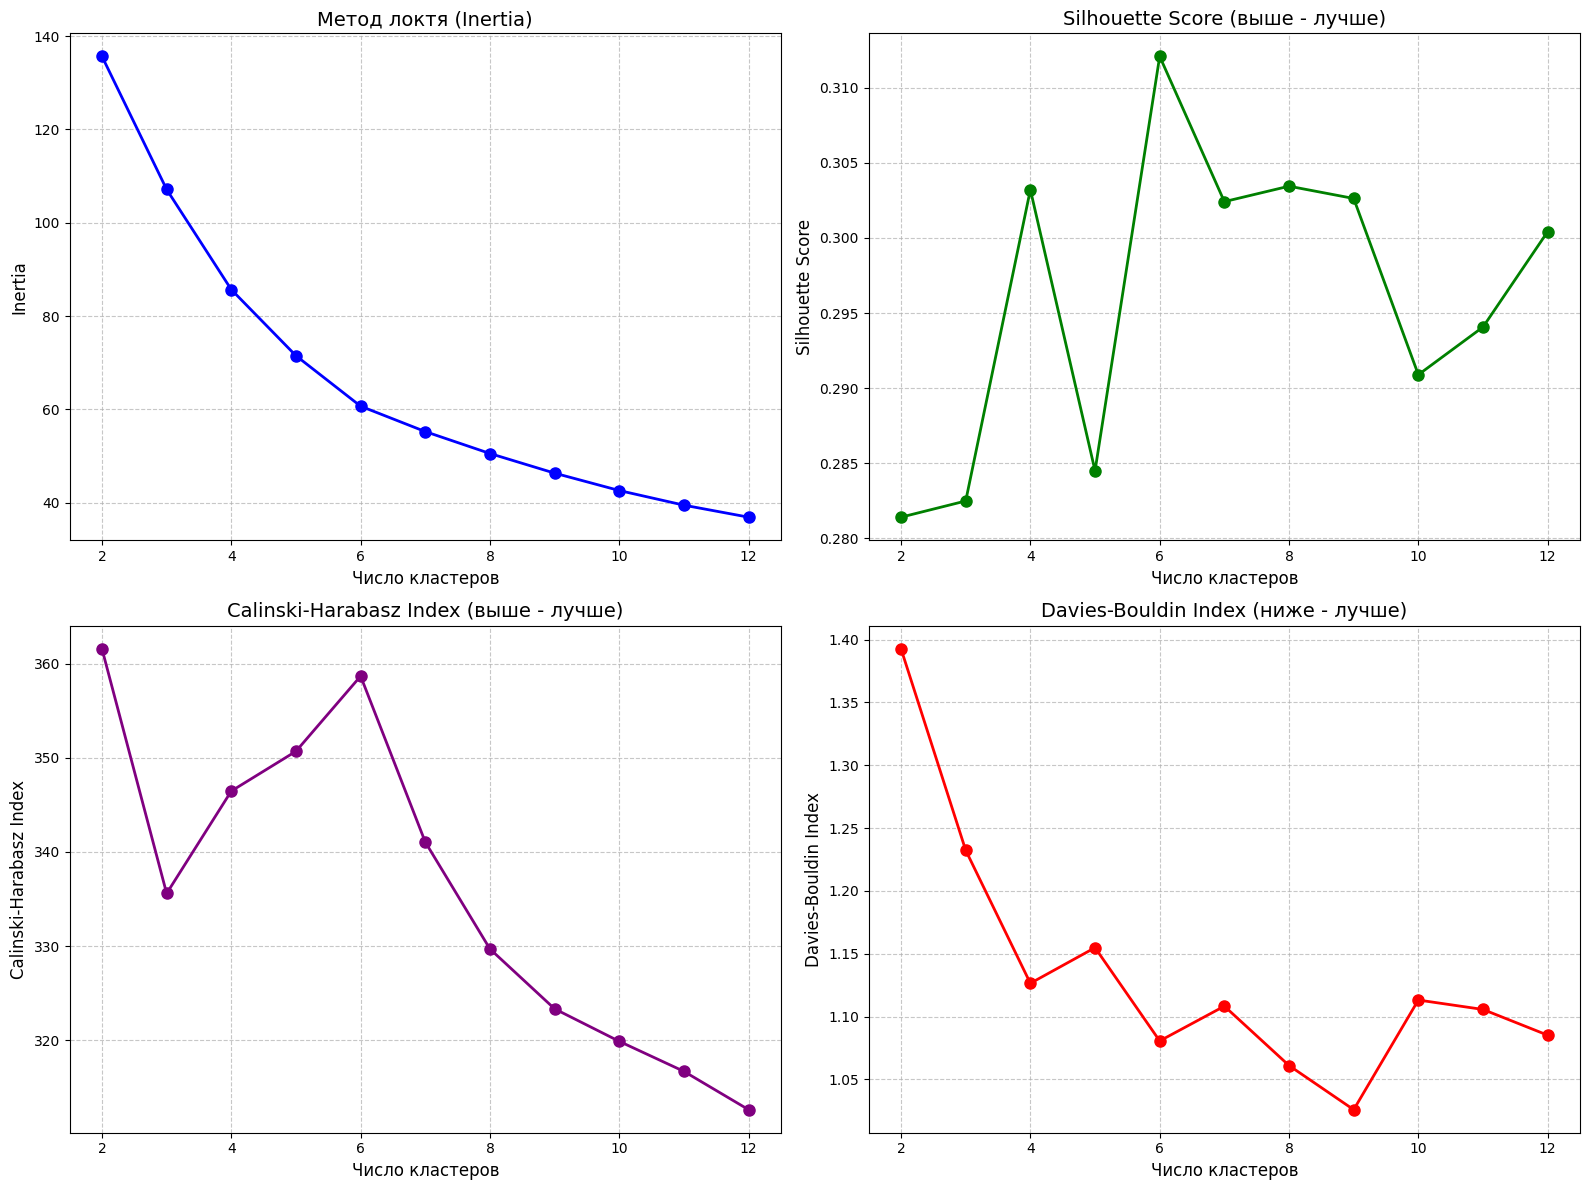


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 6
Silhouette Score: 6
Calinski-Harabasz Index: 2
Davies-Bouldin Index: 9

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,135.645715,0.281417,361.569321,1.392624
1,3,107.135670,0.282496,335.586083,1.232351
2,4,85.675104,0.303214,346.463459,1.126537
3,5,71.504537,0.284506,350.690253,1.154886
4,6,60.690261,0.312086,358.676807,1.080673
5,7,55.250689,0.302418,341.041657,1.108344
6,8,50.553552,0.303446,329.688325,1.061108
7,9,46.346273,0.302629,323.326436,1.025973
8,10,42.620609,0.290899,319.873760,1.113210
9,11,39.484743,0.294074,316.682140,1.105723


In [30]:
optimal_clusters = find_optimal_clusters(X_scaled, max_k=12)

In [37]:
# попробуем следующие кластеры, основываясь на полученных результатах

optimal_k = [3, 4, 5, 6]

Оптимальное значение eps (точка изгиба): 0.1949


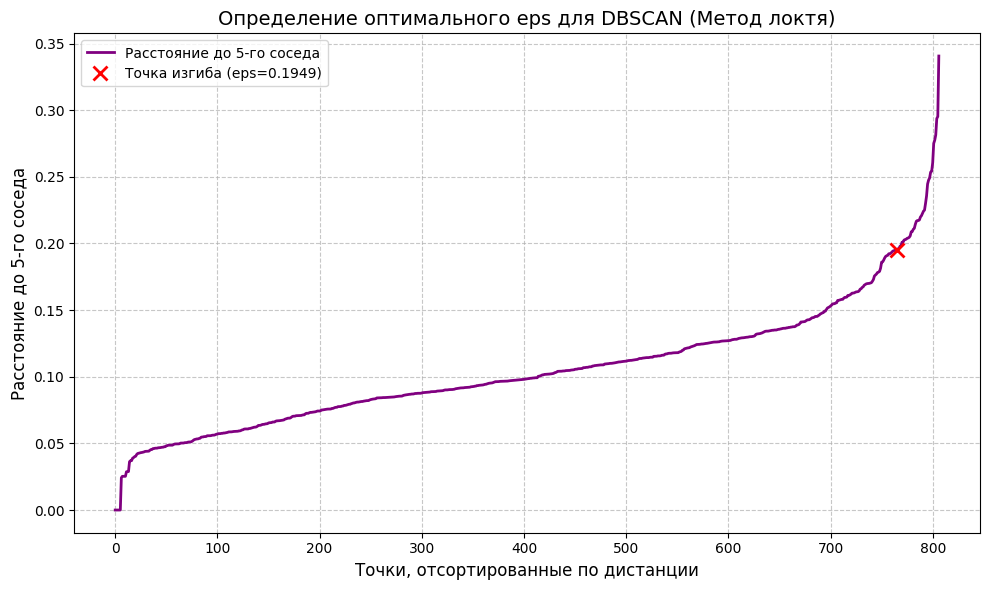

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

def find_optimal_eps(X, k=5):
    """
    Определение оптимального значения eps для алгоритма DBSCAN
    с визуализацией точки максимального изгиба.
    """
    # Находим расстояния до k-го ближайшего соседа [[1]] [[9]]
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)

    # Берем расстояние до k-го соседа (индекс k-1) и сортируем
    distances = np.sort(distances[:, k-1])
    indices = np.arange(len(distances)) # Индексы для оси X

    # Находим точку максимального изгиба (перегиба) ДО отрисовки
    kl = KneeLocator(indices, distances, curve='convex', direction='increasing')

    # Визуализируем график расстояний
    plt.figure(figsize=(10, 6))
    plt.plot(indices, distances, linewidth=2, color='purple', label=f'Расстояние до {k}-го соседа')
    plt.xlabel('Точки, отсортированные по дистанции', fontsize=12)
    plt.ylabel(f'Расстояние до {k}-го соседа', fontsize=12)
    plt.title('Определение оптимального eps для DBSCAN (Метод локтя)', fontsize=14)

    # Если точка изгиба найдена, отмечаем ее на графике
    if kl.knee is not None:
        optimal_eps = distances[kl.knee]
        plt.plot(kl.knee, optimal_eps, 'rx', markersize=10, mew=2, # Красный крестик, увеличенный размер, толщина линии
                 label=f'Точка изгиба (eps={optimal_eps:.4f})')
        print(f"Оптимальное значение eps (точка изгиба): {optimal_eps:.4f}")
    else:
        optimal_eps = None # Устанавливаем в None, если точка не найдена
        print("Не удалось автоматически определить точку изгиба.")

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend() # Показываем легенду с метками
    plt.tight_layout()
    plt.show()

    # Возвращаем найденное значение или fallback
    if optimal_eps is not None:
        return optimal_eps
    else:
        # Возвращаем примерное значение, если автоматическое определение не удалось

        eps_guess = np.percentile(distances, 10)
        print(f"Предлагаемое значение eps (10-й процентиль): {eps_guess:.4f}")
        return eps_guess


# Определяем оптимальный параметр eps для DBSCAN
optimal_eps = find_optimal_eps(X_scaled, k=5)

### **4. Сравнительный анализ алгоритмов кластеризации**


- Реализуйте и сравните следующие алгоритмы кластеризации:
  - K-means
  - Агломеративная кластеризация
  - Спектральная кластеризация
  - DBSCAN (с оптимальным значением eps)
  - HDBSCAN
- Для каждого алгоритма оцените:
  - Качество кластеризации по основным метрикам
  - Распределение точек по кластерам
  - Характерные особенности выявленных кластеров

In [39]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def evaluate_clustering(X, labels, algorithm_name):
    """
    Оценка качества кластеризации по различным метрикам
    """
    n_clusters = len(np.unique(labels))
    if -1 in labels:  # Исключаем шумовые точки для DBSCAN/HDBSCAN
        n_clusters -= 1

    metrics = {}

    if n_clusters > 1:  # Все метрики требуют минимум 2 кластера
        metrics['silhouette'] = silhouette_score(X, labels)
        metrics['calinski'] = calinski_harabasz_score(X, labels)
        metrics['davies'] = davies_bouldin_score(X, labels)
    else:
        metrics['silhouette'] = np.nan
        metrics['calinski'] = np.nan
        metrics['davies'] = np.nan

    print(f"\nМетрики качества кластеризации для {algorithm_name}:")
    print(f"Количество кластеров: {n_clusters}")
    print(f"Silhouette Score: {metrics['silhouette']:.4f}")
    print(f"Calinski-Harabasz Index: {metrics['calinski']:.4f}")
    print(f"Davies-Bouldin Index: {metrics['davies']:.4f}")
    val, cnt = np.unique(labels, return_counts=True)
    res = {}
    for i in val:
        res[i] = cnt[i]
    print("Распределение точек:")
    print(pd.DataFrame.from_dict(res, orient='index'))

    return metrics

In [40]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.cluster import DBSCAN
import hdbscan

results={}
hdbscan = hdbscan.HDBSCAN()
hdbscan_labels = hdbscan.fit_predict(X_scaled)

dbscan = DBSCAN(eps=optimal_eps)
dbscan_labels = dbscan.fit_predict(X_scaled)

hdbscan_metrics = evaluate_clustering(X_scaled, hdbscan_labels, "HDBSCAN")
dbscan_metrics = evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN")
results['DBSCAN'] = dbscan_metrics
results['HDBSCAN'] = hdbscan_metrics


for k in optimal_k:
    spectral = SpectralClustering(n_clusters=k, random_state=42, assign_labels='kmeans')
    agglom = AgglomerativeClustering(n_clusters=k)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    spectral_labels = spectral.fit_predict(X_scaled)
    agglom_labels = agglom.fit_predict(X_scaled)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    spectral_metrics = evaluate_clustering(X_scaled, spectral_labels, f"Spectral (k: {k})")
    kmeans_metrics = evaluate_clustering(X_scaled, kmeans_labels, f"KMeans (k: {k})")
    agglom_metrics = evaluate_clustering(X_scaled, agglom_labels, f"Агломеративная кластеризация (k: {k})")

    results[f'Spectral (k: {k})'] = spectral_metrics
    results[f'KMeans (k: {k})'] = kmeans_metrics
    results[f'Агломеративная (k: {k})'] = agglom_metrics


Метрики качества кластеризации для HDBSCAN:
Количество кластеров: 27
Silhouette Score: -0.1180
Calinski-Harabasz Index: 25.5878
Davies-Bouldin Index: 1.3907
Распределение точек:
       0
-1    14
 0   428
 1    33
 2    14
 3     8
 4    16
 5    14
 6     5
 7     8
 8     5
 9    21
 10   18
 11    6
 12   53
 13   22
 14   21
 15    6
 16    5
 17   15
 18   13
 19    8
 20    6
 21   23
 22    6
 23    9
 24    7
 25    7
 26   16

Метрики качества кластеризации для DBSCAN:
Количество кластеров: 5
Silhouette Score: 0.0809
Calinski-Harabasz Index: 31.1192
Davies-Bouldin Index: 1.1740
Распределение точек:
      0
-1    3
 0   11
 1  752
 2   31
 3    5
 4    5

Метрики качества кластеризации для Spectral (k: 3):
Количество кластеров: 3
Silhouette Score: 0.2829
Calinski-Harabasz Index: 321.2289
Davies-Bouldin Index: 1.2085
Распределение точек:
     0
0  305
1  423
2   79

Метрики качества кластеризации для KMeans (k: 3):
Количество кластеров: 3
Silhouette Score: 0.2825
Calinski-Harab

In [41]:
pd.DataFrame.from_dict(results, orient='index').sort_values(by='silhouette', ascending=False)

,silhouette,calinski,davies
KMeans (k: 6),0.312086,358.676807,1.080673
Spectral (k: 5),0.307052,320.626600,1.101210
KMeans (k: 4),0.303214,346.463459,1.126537
Spectral (k: 4),0.291464,325.106670,1.094138
KMeans (k: 5),0.284506,350.690253,1.154886
Spectral (k: 3),0.282924,321.228944,1.208516
KMeans (k: 3),0.282496,335.586083,1.232351
Spectral (k: 6),0.275548,301.342676,1.053142
Агломеративная (k: 6),0.265442,291.804527,1.095102
Агломеративная (k: 5),0.250019,278.601446,1.197120


По всем характристикам KMeans с K=6 показала себя лучше всего, но такое количество кластеров будет сложно описывать, поэтому попробуем взять следующую из списка KMeans с K=4.

In [47]:
best_model = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = best_model.fit_predict(X_scaled)

### **5. Визуализация и интерпретация результатов**


- Визуализируйте результаты кластеризации на карте с использованием leafmap
- Постройте тепловые карты средних значений экологических факторов для каждого кластера
- Выполните снижение размерности с помощью PCA и визуализируйте кластеры в двумерном пространстве
- Проанализируйте профили кластеров и составьте их экологические характеристики
- Разработайте рекомендации по улучшению экологической обстановки для каждого типа территории

In [48]:
# Добавляем метки кластеров в исходный GeoDataFrame
h3_gdf_viz['cluster'] = labels.astype("str")

# Создаем карту с кластерами
map_clusters = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
map_clusters.add_data(
    h3_gdf_viz,
    column="cluster",
    cmap="OrRd_r",
    scheme='EqualInterval',
    legend_title="Кластеры",
    layer_name="H3 Кластеризация",
    style={
        "stroke": False,
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
    info_mode='on_click'
)

# Отображаем карту
map_clusters

Map(center=[55.983599999999996, 37.2016], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_…

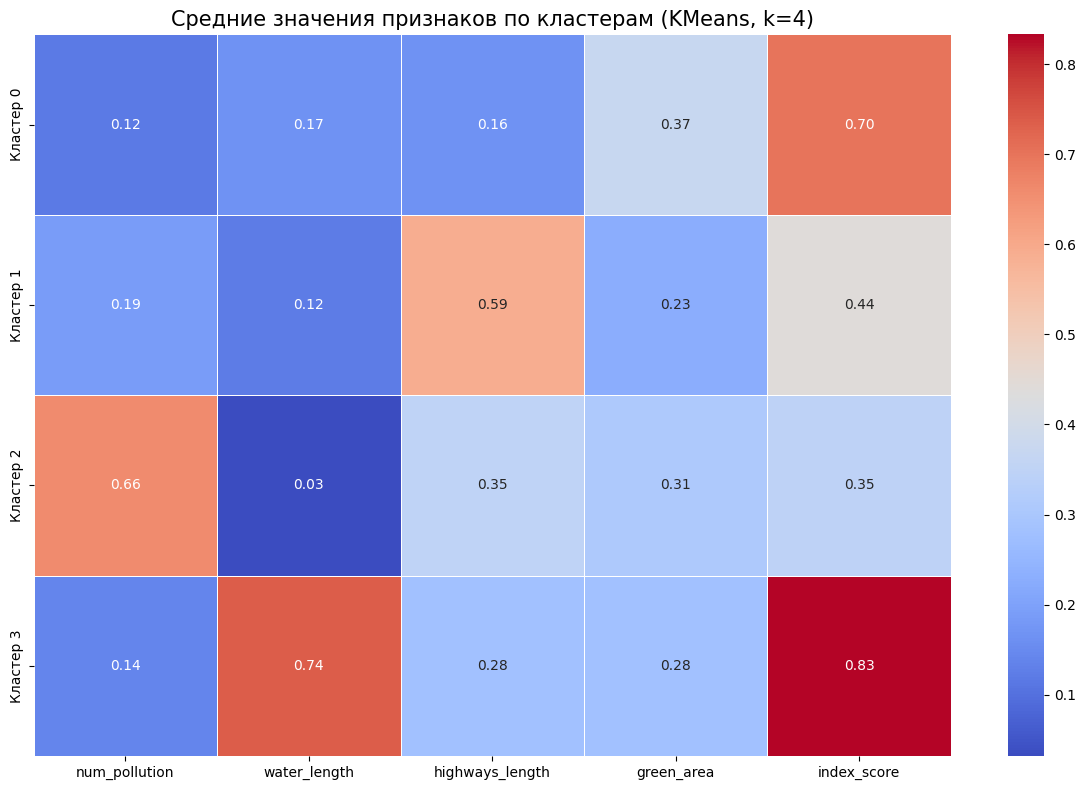

In [49]:
import seaborn as sns

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)

scaler = MinMaxScaler()
X_scaled2 = scaler.fit_transform(X)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X_scaled2[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features2
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans, k=4)', fontsize=15)
plt.tight_layout()
plt.show()

In [51]:
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled2)

fig = px.scatter(X_pca, x=0, y=1, color=labels.astype("str"), title="Распределение ячеек по кластерам (KMeans, K=4)", labels={'0': 'PC1', '1': 'PC2', 'color': 'Кластер'}
)
fig.show()

In [54]:
h3_gdf_viz['cluster'].value_counts(normalize=True).sort_index() * 100

,proportion
cluster,
0,45.229244
1,28.748451
2,13.382900
3,12.639405


**Кластер 0 (45% всех зон):** жилые и парковые зоны с благоприятной экологической обстановкой. Низкая плотность источников загрязнения (0.12), умеренное озеленение (0.37 — самое высокое среди кластеров), незначительная транспортная нагрузка. Индекс экологического благополучия высокий (0.70). Это типичные спальные районы и рекреационные территории Зеленограда.

**Кластер 1 (29% всех зон):** транспортные коридоры и придорожные территории. Доминирующая характеристика — высокая протяжённость автомагистралей (0.59). Источников загрязнения немного, зелёных и водных объектов мало. Индекс благополучия средний (0.44). Это зоны вблизи крупных дорог (Ленинградское шоссе, Федеральная трасса М-10).

**Кластер 2 (13% всех зон):** наиболее проблемные территории с высокой антропогенной нагрузкой. Максимальная плотность источников загрязнения (0.66), практически отсутствуют водные объекты (0.03), высокая транспортная нагрузка (0.35). Индекс экологического благополучия — наинизший среди всех кластеров (0.35). Это промышленные зоны, плотная застройка и узлы транспортной инфраструктуры.

**Кластер 3 (13% всех зон):** природные и водоохранные зоны. Абсолютное доминирование водных объектов (0.74), минимальное загрязнение (0.14). Индекс экологического благополучия — наивысший (0.83). Это берега рек и озёр (Сходня, Черногрудка, водохранилища), лесные массивы и природные территории.

***РЕКОМЕНДАЦИИ***

**Кластер 0**

- Сохранять и расширять существующие зелёные насаждения, предотвращать их вырубку при застройке.
- Развивать дворовое озеленение: высаживать деревья и кустарники в жилых кварталах.
- Контролировать качество воздуха, так как близость к транспортным зонам может повышать уровень загрязнения.

**Кластер 1**

- Создать «зелёные коридоры» вдоль магистралей — полосы из деревьев и кустарников для снижения шума, пыли и выбросов.
- Установить шумозащитные экраны вблизи жилых домов.
- Ограничить движение грузового транспорта в ночное время.

**Кластер 2**

- Провести учет всех источников загрязнения и разработать план снижения количества отдходов или переноса некоторых предприятий.
- Рекультивировать загрязнённые территории, создать буферные зелёные зоны между промышленными объектами и жильём.
- Развивать эколгичный общественный транспорт и велоинфраструктуру для снижения автомобильной нагрузки.
- Ввести строгий контроль выбросов на производствах.

**Кластер 3**

- Ввести режим особой охраны водоохранных зон: запрет на строительство, ограничение хозяйственной деятельности.
- Восстанавливать и поддерживать естественные экосистемы: убирать инвазивные виды, высаживать местные растения, запретить охоту.
- Организовать регулярный контроль качества воды и состояния береговых линий.

### **6. Разработка моделей классификации**


- На основе результатов лучшего алгоритма кластеризации подготовьте данные для обучения классификаторов
- Обучите и сравните различные модели классификации:
  - Логистическая регрессия
  - Дерево решений
  - Случайный лес
  - Градиентный бустинг
  - SVM
  - K-ближайших соседей
- Оцените качество моделей с использованием кросс-валидации
- Выберите оптимальную модель и сохраните её для дальнейшего использования

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled2, labels, test_size=0.3, random_state=42)
X_train.shape, X_test.shape

((564, 5), (243, 5))

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

predictions = {}
models = {
    'Logistical Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(),
    'KNN': KNeighborsClassifier(n_neighbors=4)
}
for name in models:
  models[name].fit(X_train, y_train)
  predictions[name] = models[name].predict(X_test)

In [57]:
from sklearn.metrics import classification_report

for model in predictions.keys():
  report = classification_report(y_test, predictions[model])
  print(f'{model}:')
  print(report)

Logistical Regression:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       122
           1       0.94      0.99      0.96        68
           2       1.00      0.81      0.89        31
           3       0.95      0.91      0.93        22

    accuracy                           0.95       243
   macro avg       0.96      0.92      0.94       243
weighted avg       0.95      0.95      0.95       243

Decision Tree:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       122
           1       0.97      0.97      0.97        68
           2       0.96      0.84      0.90        31
           3       1.00      1.00      1.00        22

    accuracy                           0.97       243
   macro avg       0.97      0.95      0.96       243
weighted avg       0.97      0.97      0.97       243

Random Forest:
              precision    recall  f1-score   support

           0       0.9

In [58]:
# Кросс-валидация

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.model_selection import KFold

def cross_validate(model, n_splits=None):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    f1_scores = []
    acc_scores = []
    prec_scores = []
    rec_scores = []

    for train_index, test_index in cv.split(X_scaled2, None):
        X_train, X_test = X_scaled2[train_index], X_scaled2[test_index]
        y_train, y_test = labels[train_index], labels[test_index]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        f1 = f1_score(y_test, y_pred, average='macro')
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro')
        rec = recall_score(y_test, y_pred, average='macro')

        f1_scores.append(f1)
        acc_scores.append(acc)
        prec_scores.append(prec)
        rec_scores.append(rec)

    f1_mean = np.mean(f1_scores)
    acc_mean = np.mean(acc_scores)
    prec_mean = np.mean(prec_scores)
    rec_mean = np.mean(rec_scores)

    return {'F1': f1_mean, 'Accuracy': acc_mean, 'Precision': prec_mean, 'Recall': rec_mean}

In [59]:
res = {}
for name in models:
  res[name] = cross_validate(models[name], 5)

finale = pd.DataFrame.from_dict(res, orient='index').sort_values('F1', ascending=False)
finale

,F1,Accuracy,Precision,Recall
Gradient Boosting,0.974182,0.977678,0.974823,0.973963
Random Forest,0.971087,0.973974,0.973456,0.969042
SVC,0.963111,0.969028,0.978880,0.950308
Decision Tree,0.952639,0.960325,0.957010,0.950667
Logistical Regression,0.940127,0.950426,0.964456,0.922070
KNN,0.933643,0.943057,0.957927,0.915065


In [60]:
# лучшая модель

import joblib

best_model_name = finale.iloc[0].name
best_model = models[best_model_name]
display(best_model)

joblib.dump(best_model, 'best_ecology_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Лучшая модель ({best_model_name}) сохранена в 'best_ecology_model.pkl'")
print(f"Scaler сохранён в 'scaler.pkl'")

GradientBoostingClassifier(random_state=42)

Лучшая модель (Gradient Boosting) сохранена в 'best_ecology_model.pkl'
Scaler сохранён в 'scaler.pkl'


## **Требования к отчету (Структуре блокнота)**



1. Описание выбранной территории и источников данных
2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов
3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма
4. Карты распределения экологических факторов и результатов кластеризации
5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию
6. Анализ эффективности разработанных моделей классификации
7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов

# **Отчет**

**1. Описание выбранной территории и источников данных**

Выбранная территория - город и административный округ Москвы. Это небольшая территория, но она включает в себя всё разнообразие городской инфраструктуры - жилые массивы, промзоны, крупные дорожные магистрали, парки и лесные массивы.

Источники данных:
  -  Геопространственные данные из OpenStreetMap

**2. Методика расчета экологических показателей с обоснованием выбора буферных зон и весовых коэффициентов**

**Плотность загрязнения**, ПЗ (num_pollution) — количество точечных источников загрязнения в ячейке.

**Протяжённость дорог** (ПД) и **водных объектов** (ВО) — суммарная длина линейных объектов в пределах ячейки.

**Доля зелёных зон**, ЗЗ (green_area) — количество зелёных насаждений, лесов в ячейке.

Для нормализации признаков в диапазон [0, 1] был применен MinMaxScaler.

Интегральный индекс (index_score) для оценки каждой ячейки был рассчитан интуитивно понятные образом - сложить позитивные факторы и вычесть негативные:

`index_score = ВО+ЗЗ-ПД-ПЗ`

**3. Сравнительный анализ результатов кластеризации с обоснованием выбора оптимального алгоритма**

При анализе алгоритмов лучше всего себя показывали KMeans и Спектральная кластеризации, был выбран вариант с наименьшим количеством кластеров (4) и самыми лучшими показателями метрик - KMeans. Это было сделано для удобства интерпретации результатов. Наилучшие результаты показывала KMeans(K=6) и Spectral(K=5).

DBSCAN и HDBSCAN хорошо выявляют аномалии в данных, но не подошли для данной задачи, у них были  худшие или отрицательные показатели метрик.

**4. Карты распределения экологических факторов и результатов кластеризации**

см. пункт 5

**5. Подробная характеристика выявленных экологических зон (кластеров) с рекомендациями по их развитию**

см. конец пункта 5

**6. Анализ эффективности разработанных моделей классификации**

Все модели классификации показали отличные результаты, все метрики имеют значение не ниже 0.92. Лучшая модель GradientBoostingClassifier с F1-Score = 	0.974182 (характеризует количество ложных срабатываний и  правильных срабатываний на целевые объекты (баланс между точностью (precision) и полнотой (recall))

**7. Выводы об экологическом состоянии исследуемой территории и возможностях практического применения полученных результатов**

На территория Зеленограда преобладают экологически благополучные зоны (45% жилых/озеленненных зон + 13% лесные массивы/водоохранные зоны)

Лишь 13% процентов территории приходится на экологически неблагоприятные промзоны.

29% процентов проблемных зон обсловны близостью дорожной инфраструктуры, необходимой каждому современному городу.

Были вынесены рекомендации по озеленению и улучшению экологической обстановки в каждой из 4 городских зон.

Интегральный индекс и кластеризация позволили распределить территории по приоритету повышения экологического благополучия.

Результаты можно использовать:

  - Для обоснования размещения новых зелёных зон;
  - Для проектирования и строительства новых объектов;
  - Для создания проектов по улучшению экологической обсановки в городе.